## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Regressor Model**</span>

```py   
@ex.config
def config():
    # Global configuration:
    seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  #  
    deltas = [1] # ,2,3,4
    shapes = [(15,15)] # , (20,20), (25,25), (30,30)

    path2save:str = './Data'
    n_hidden_filters:list[int] = [1,15,32,64]
    kernel_size:int = 3
    mlp_hidden:tuple[int] = (64,32)
    use_stats:bool = False  
    padding_mode:str = 'circular'
    optimizer:str = 'Adam'
    learning_rate:float = 0.0001
    epochs:int = 10
    batch_size:int = 2**8
    metrics2compute:list= ['MeanAbsoluteError', 'MeanSquaredError', 'R2Score']
```

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from pathlib import Path
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (15,15)
parent_folder = './Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

cols2omit = 0
num_rows = 1

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoL Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

metrics2compute = ['Accuracy', 'Recall', 'Specificity','Precision', 'F1Score']

model_hp = {'n_hidden_filters':[1,15,32,64], 'kernel_size':3, 'mlp_hidden':(64,32), 'use_stats':False, 'padding_mode':'circular'}

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta)
test_data = eval_tools.get_paths_results('testGoL.csv', parent_folder, seeds, shape, delta)
confusion_matrix = eval_tools.get_paths_results('confusion_matrix.csv', parent_folder, seeds, shape, delta)
paths2model = eval_tools.get_paths_results('model.pt',parent_folder, seeds, shape, delta)
tabs2plot = Path(parent_folder)/'tabs2plot_221.csv'

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.0041 ± 0.0000
val_loss: 0.0042 ± 0.0000


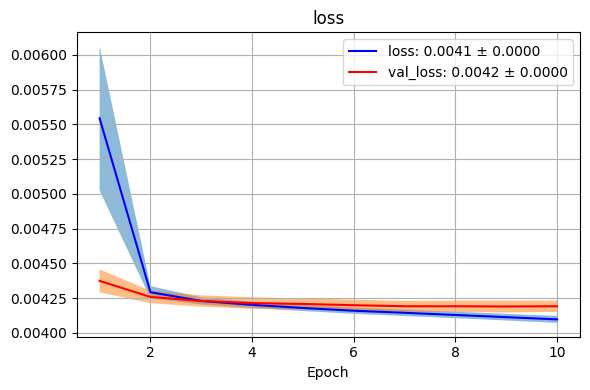

In [3]:
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results using Global thresholding of 0.5**</u></span>

In [ ]:
# Global threshold of 0.5
eval_tools.computeCM_direct(confusion_matrix, shape, metrics2compute)

--- Results Initial states (15 seeds) ---
Accuracy: 0.8394 ± 0.0000
Recall: 0.6097 ± 0.0000
Specificity: 0.9055 ± 0.0000
Precision: 0.6502 ± 0.0000
F1Score: 0.6293 ± 0.0000


### <span style='color:rgb(10,110,217)'><u>**Test Results using Regressor model**</u></span>

In [4]:
eval_tools.display_test_results(test_results_paths,cols2omit)

--- Metrics computed during execution ---
MeanAbsoluteError: 0.1162 ± 0.0002
MeanSquaredError: 0.0286 ± 0.0001
R2Score: 0.1481 ± 0.0043


In [ ]:
eval_tools.computeCM(confusion_matrix, predictions_paths, metrics2compute, shape)

--- Results Initial states (15 seeds) ---
Accuracy: 0.8070 ± 0.0008
Recall: 0.7520 ± 0.0017
Specificity: 0.8261 ± 0.0017
Precision: 0.5534 ± 0.0017
F1Score: 0.6319 ± 0.0005


### <span style='color:rgb(10,110,217)'><u>**Test Results using Otsu method**</u></span>

In [19]:
thresholds_otsu = eval_tools.computeOtsu(confusion_matrix, shape)
eval_tools.computeCM_Otsu(confusion_matrix, thresholds_otsu, shape, metrics2compute)

--- Results Initial states (15 seeds) ---
Accuracy: 0.8361 ± 0.0000
Recall: 0.6610 ± 0.0000
Specificity: 0.8894 ± 0.0000
Precision: 0.6481 ± 0.0000
F1Score: 0.6513 ± 0.0000


### <span style='color:rgb(10,110,217)'><u>**Test Results using Gaussian thresholding**</u></span>

In [25]:
eval_tools.computeCM_Gauss(confusion_matrix, shape, metrics2compute)

--- Results Initial states (15 seeds) ---
Accuracy: 0.7912 ± 0.0000000000
Recall: 0.6540 ± 0.0000000000
Specificity: 0.8307 ± 0.0000000000
Precision: 0.5266 ± 0.0000000000
F1Score: 0.5834 ± 0.0000000000


### <span style='color:rgb(10,110,217)'><u>**Visual plot using regressor model thresholding**</u></span>

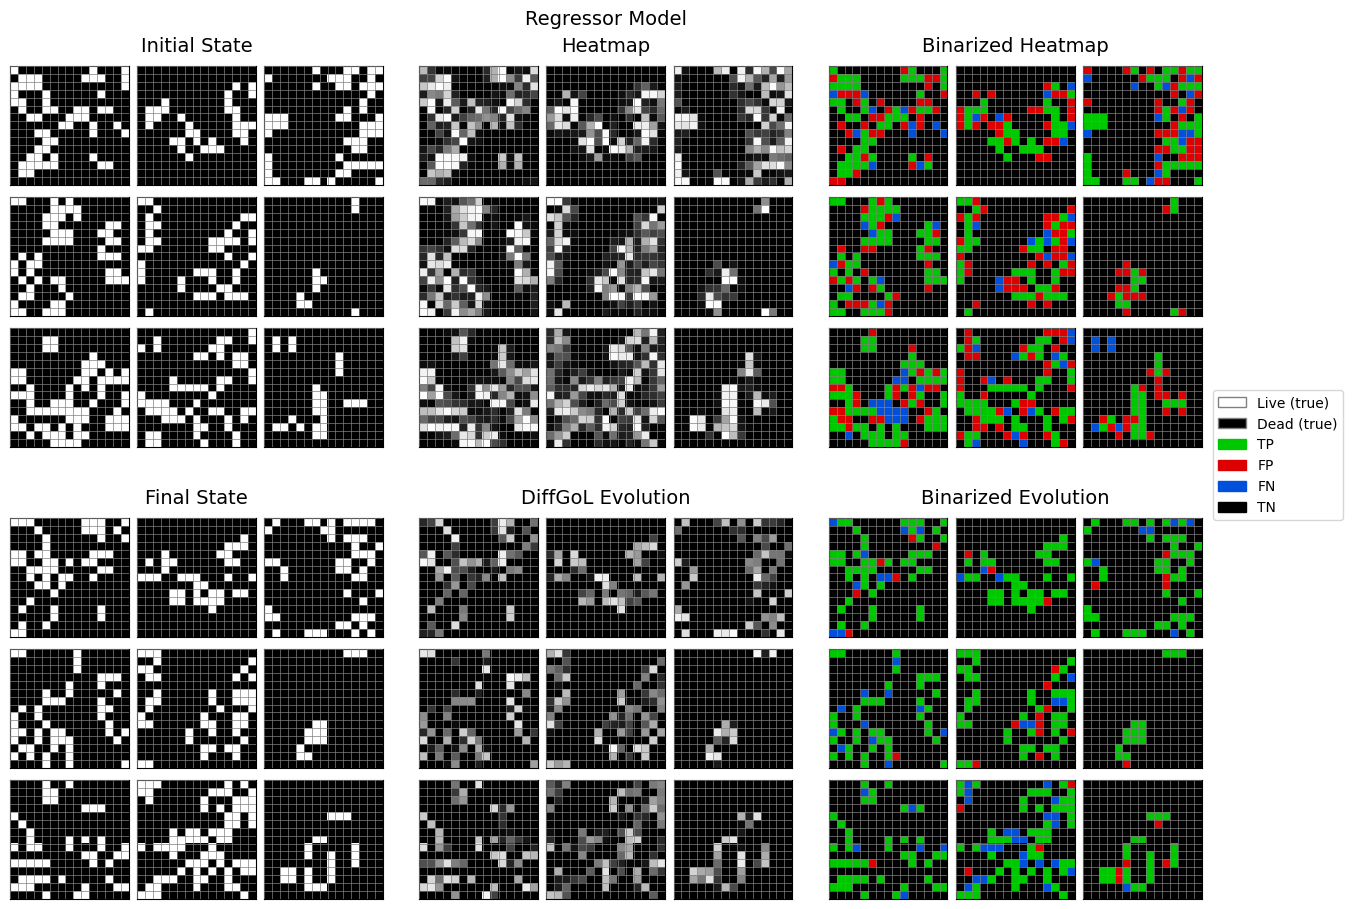

In [23]:
eval_tools.display_states(tabs2plot, paths2model, shape, model_hp)